In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import sys

print(sys.executable)
import pandas as pd

print(pd.__version__)
df = pd.read_csv("../data/sales_data.csv")

df.head()

c:\Program Files\Python314\python.exe
3.0.6


,Order_ID,Date,Customer,City,Product,Quantity,Unit_Price
0,1001,2026-02-27,Jay Ambe Traders,Rajkot,Wall Putty,22,500
1,1002,2026-03-13,New Gujarat Sales,Surat,Wall Putty,48,500
2,1003,2026-08-05,Shree Sales,Rajkot,Wall Putty,6,500
3,1004,2026-04-30,ABC Traders,Rajkot,Exterior Paint,43,1100
4,1005,2026-08-03,Mahalaxmi Enterprise,Gandhinagar,Primer,33,650


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()
df.describe()

Rows: 300
Columns: 7
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Order_ID    300 non-null    int64
 1   Date        300 non-null    str  
 2   Customer    300 non-null    str  
 3   City        300 non-null    str  
 4   Product     300 non-null    str  
 5   Quantity    300 non-null    int64
 6   Unit_Price  300 non-null    int64
dtypes: int64(3), str(4)
memory usage: 16.5 KB


,Order_ID,Quantity,Unit_Price
count,300.000000,300.000000,300.000000
mean,1150.500000,27.890000,708.666667
std,86.746758,13.274233,250.066658
min,1001.000000,5.000000,450.000000
25%,1075.750000,16.000000,500.000000
50%,1150.500000,28.000000,650.000000
75%,1225.250000,39.000000,900.000000
max,1300.000000,50.000000,1100.000000


In [6]:
df.isnull().sum()

Order_ID      0
Date          0
Customer      0
City          0
Product       0
Quantity      0
Unit_Price    0
dtype: int64

In [7]:
df["Date"] = pd.to_datetime(df["Date"])


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order_ID    300 non-null    int64         
 1   Date        300 non-null    datetime64[us]
 2   Customer    300 non-null    str           
 3   City        300 non-null    str           
 4   Product     300 non-null    str           
 5   Quantity    300 non-null    int64         
 6   Unit_Price  300 non-null    int64         
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 16.5 KB


In [10]:
df["Sales"] = df["Quantity"] * df["Unit_Price"]
df.head()

,Order_ID,Date,Customer,City,Product,Quantity,Unit_Price,Sales
0,1001,2026-02-27,Jay Ambe Traders,Rajkot,Wall Putty,22,500,11000
1,1002,2026-03-13,New Gujarat Sales,Surat,Wall Putty,48,500,24000
2,1003,2026-08-05,Shree Sales,Rajkot,Wall Putty,6,500,3000
3,1004,2026-04-30,ABC Traders,Rajkot,Exterior Paint,43,1100,47300
4,1005,2026-08-03,Mahalaxmi Enterprise,Gandhinagar,Primer,33,650,21450


In [11]:
total_sales = df["Sales"].sum()

print("Total Sales:", total_sales)

total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

average_order_value = df["Sales"].mean()

print("Average Order Value:", round(average_order_value, 2))

Total Sales: 5986550
Total Quantity Sold: 8367
Average Order Value: 19955.17


In [13]:
product_sales = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)

city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(city_sales)

customer_sales = (
    df.groupby("Customer")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_sales.head(10))

Product
Exterior Paint    1907400
Wall Texture      1467900
Wall Putty         921500
Primer             871650
Distemper          818100
Name: Sales, dtype: int64
City
Mehsana        942500
Anand          839250
Rajkot         793050
Gandhinagar    789300
Ahmedabad      764650
Nadiad         683950
Surat          680800
Vadodara       493050
Name: Sales, dtype: int64
Customer
Shivam Traders          611950
Krishna Enterprise      595700
Jay Ambe Traders        525350
Ganesh Traders          446150
Shakti Traders          424050
ABC Traders             417200
New Gujarat Sales       393950
Mahalaxmi Enterprise    386700
Shree Sales             371650
Maruti Hardware         366750
Name: Sales, dtype: int64


In [14]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
)

print(monthly_sales)

Month
2026-01    731250
2026-02    975000
2026-03    651950
2026-04    491850
2026-05    587350
2026-06    679100
2026-07    708650
2026-08    796400
2026-09    365000
Freq: M, Name: Sales, dtype: int64


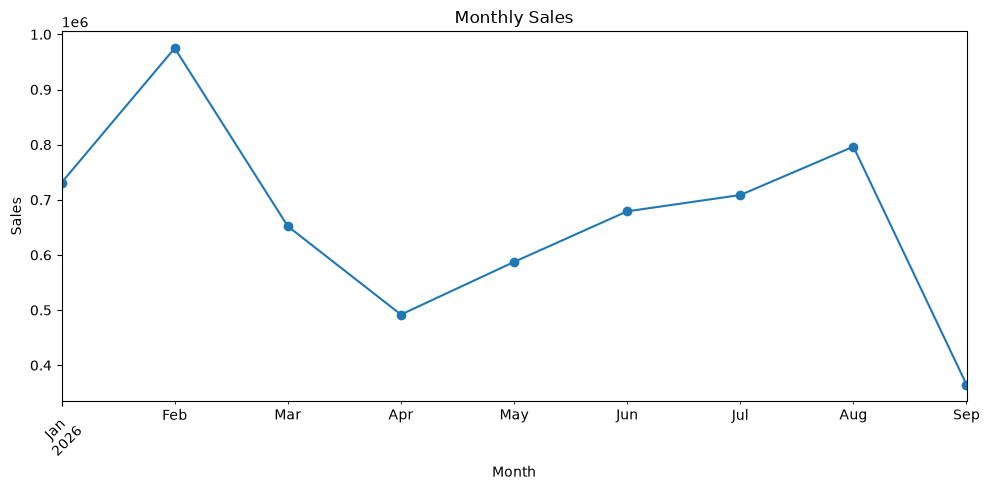

In [15]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/monthly_sales.png")

plt.show()

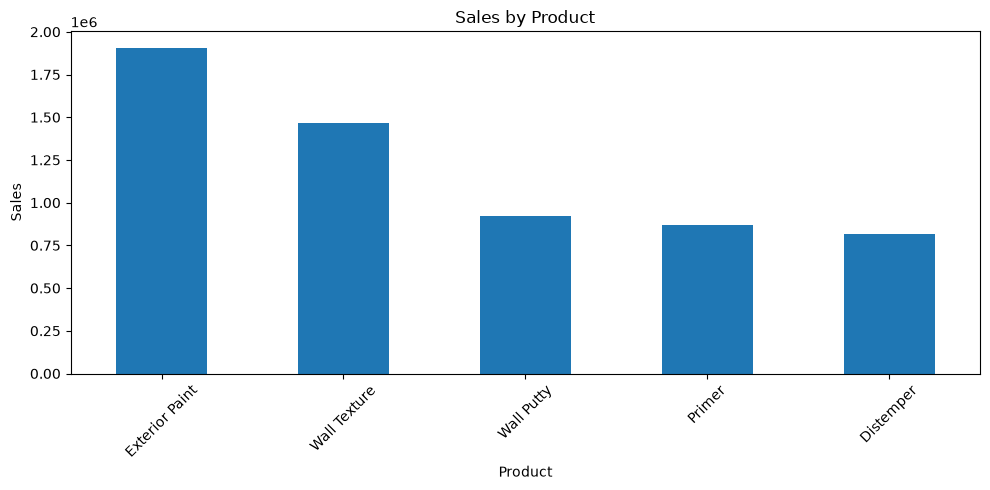

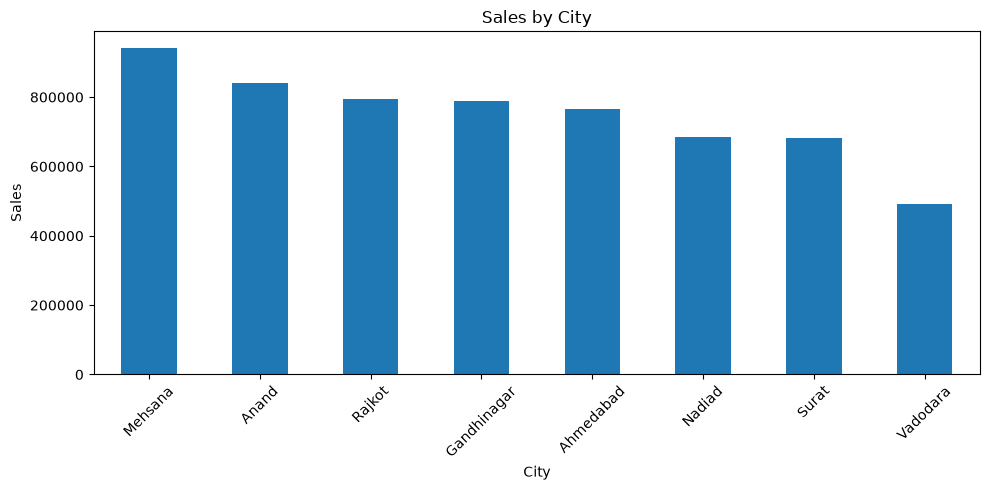

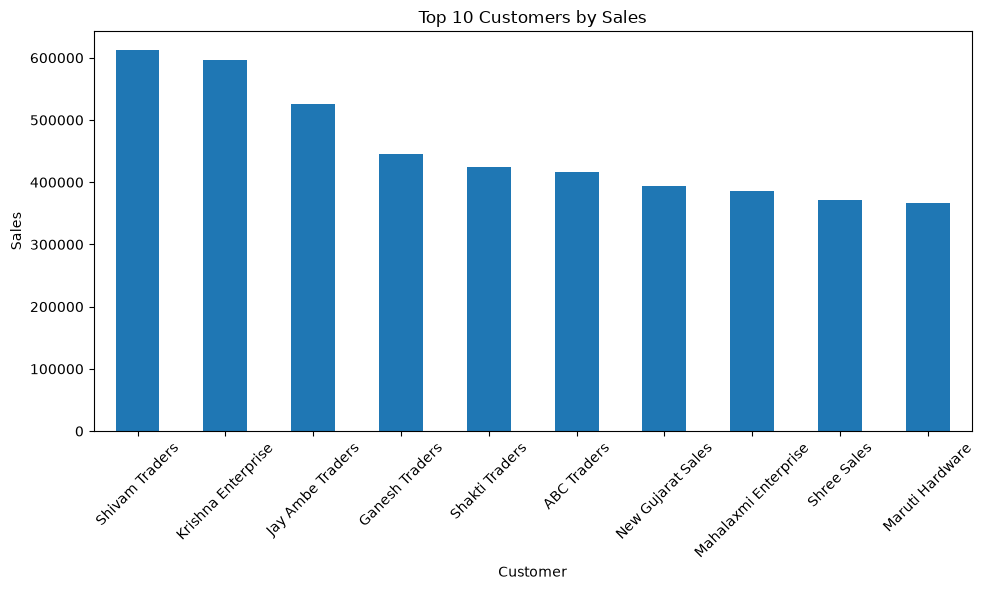

In [16]:
plt.figure(figsize=(10, 5))

product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/product_sales.png")

plt.show()

plt.figure(figsize=(10, 5))

city_sales.plot(kind="bar")

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/city_sales.png")

plt.show()

top_customers = customer_sales.head(10)

plt.figure(figsize=(10, 6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/top_customers.png")

plt.show()

            Quantity  Unit_Price     Sales
Quantity    1.000000    0.057567  0.778251
Unit_Price  0.057567    1.000000  0.615574
Sales       0.778251    0.615574  1.000000


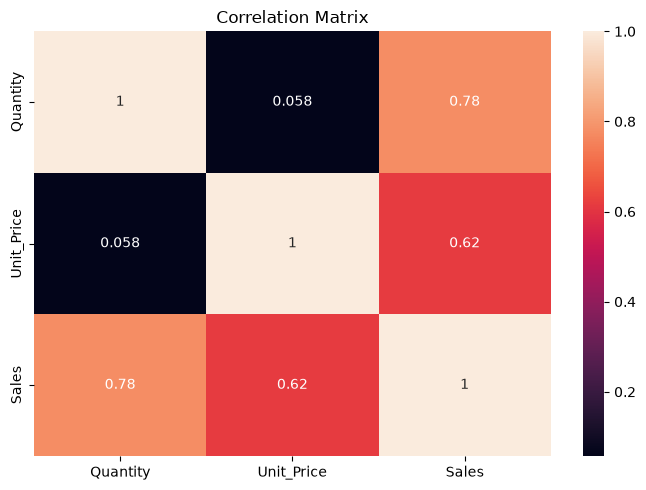

In [18]:
numeric_data = df[
    ["Quantity", "Unit_Price", "Sales"]
]

correlation = numeric_data.corr()

print(correlation)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("../images/correlation_matrix.png")

plt.show()

In [19]:
best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

best_city = city_sales.idxmax()
best_city_sales = city_sales.max()

best_customer = customer_sales.idxmax()
best_customer_sales = customer_sales.max()

best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("===== BUSINESS INSIGHTS =====")

print(
    f"Best Product: {best_product} "
    f"with sales of {best_product_sales}"
)

print(
    f"Best City: {best_city} "
    f"with sales of {best_city_sales}"
)

print(
    f"Top Customer: {best_customer} "
    f"with sales of {best_customer_sales}"
)

print(
    f"Best Month: {best_month} "
    f"with sales of {best_month_sales}"
)

===== BUSINESS INSIGHTS =====
Best Product: Exterior Paint with sales of 1907400
Best City: Mehsana with sales of 942500
Top Customer: Shivam Traders with sales of 611950
Best Month: 2026-02 with sales of 975000


In [20]:
print("Sales analysis completed successfully!")

Sales analysis completed successfully!
